# Practice 13 — Training Example

기본 학습 파이프라인에 **일반적으로 도입되는 기법들** (가중치 초기화 · BatchNorm · Dropout · L2 weight decay) 을 한꺼번에 적용해서, 학습이 얼마나 개선되는지 한 눈에 봅니다.

| 모델 | 적용 기법 |
|------|-----------|
| **Baseline** | 기본 MLP, 추가 기법 없음 |
| **Improved** | He 초기화 + BatchNorm + Dropout(0.3) + L2 (weight_decay=1e-3) |

같은 데이터·같은 학습 횟수에서 Test Accuracy 가 어떻게 달라지는지 비교합니다.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 준비
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target)
mu, sigma = X_train.mean(0), X_train.std(0) + 1e-8
X_train_s = (X_train - mu) / sigma
X_test_s  = (X_test  - mu) / sigma
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_s), torch.LongTensor(y_train)),
    batch_size=32, shuffle=True)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_s), torch.LongTensor(y_test)),
    batch_size=64)

print(f'device: {device}, Train: {len(y_train)}, Test: {len(y_test)}')


device: cuda, Train: 1437, Test: 360


---
## `train` / `evaluate` 함수

In [2]:
# 학습 - epochs 만큼 학습 + 매 epoch 평가
# (train_losses, test_losses, test_accs) 반환
def train(model, train_loader, test_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_loss = loss_sum / count
        test_loss, test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
    return train_losses, test_losses, test_accs


# 평가 - (loss, accuracy) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
    return loss_sum / count, correct / count


---
## Baseline — 기본 MLP (아무 기법 적용 안 함)

In [3]:
torch.manual_seed(42)
model_base = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
opt_base = torch.optim.Adam(model_base.parameters(), lr=1e-3)
tl_base, vl_base, va_base = train(model_base, train_loader, test_loader, opt_base, epochs=50, device=device)
print(f'Baseline final test acc: {va_base[-1]:.4f}')


Baseline final test acc: 0.9778


---
## Improved — He 초기화 + BatchNorm + Dropout + L2

- **He 초기화** (Kaiming): ReLU 와 짝, 깊은 네트워크에서 gradient 폭주/소멸 완화
- **BatchNorm1d**: 층 출력 분포 안정화 → 더 큰 learning rate 가능
- **Dropout(0.3)**: 학습 시 노드 30% 랜덤 비활성화 → 과적합 억제
- **L2 (weight_decay=1e-3)**: 가중치 크기에 벌칙 → 더 부드러운 결정 경계


In [4]:
torch.manual_seed(42)
model_imp = nn.Sequential(
    nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10)
)
# He(Kaiming) 초기화 - ReLU와 짝
for m in model_imp:
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
model_imp = model_imp.to(device)
opt_imp = torch.optim.Adam(model_imp.parameters(), lr=1e-3, weight_decay=1e-3)  # L2
tl_imp, vl_imp, va_imp = train(model_imp, train_loader, test_loader, opt_imp, epochs=50, device=device)
print(f'Improved final test acc: {va_imp[-1]:.4f}')


Improved final test acc: 0.9806


---
## 비교

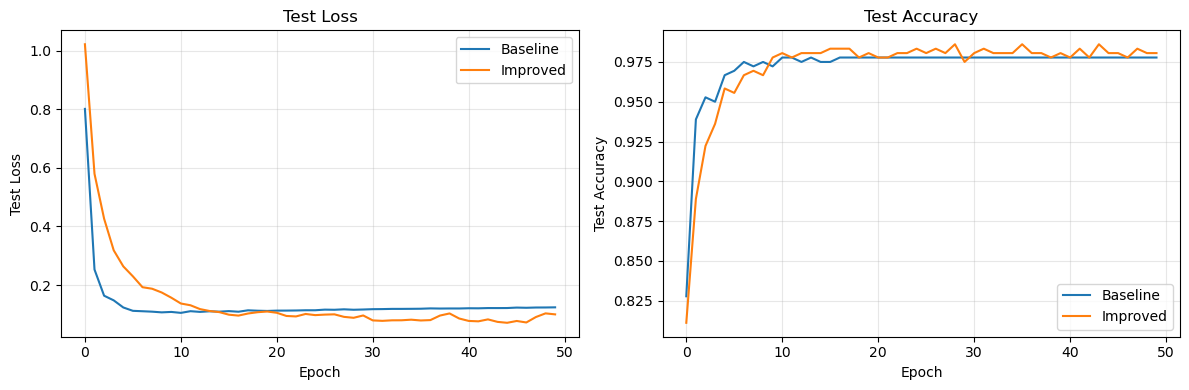

Baseline final test acc: 0.9778
Improved final test acc: 0.9806


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vl_base, label='Baseline')
axes[0].plot(vl_imp,  label='Improved')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Test Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(va_base, label='Baseline')
axes[1].plot(va_imp,  label='Improved')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Baseline final test acc: {va_base[-1]:.4f}')
print(f'Improved final test acc: {va_imp[-1]:.4f}')


---
## 정리

기본 MLP 에 표준 기법 4가지만 추가해도 Test Accuracy 가 눈에 띄게 개선됩니다. 각 기법의 세부 동작은 별도 심화 자료에서 깊게 다룰 수 있습니다.

| 기법 | 효과 |
|------|------|
| He 초기화 | 깊은 네트워크에서 gradient 폭주/소멸 완화 |
| BatchNorm | 층 출력 분포 안정화 → 더 큰 learning rate 가능 |
| Dropout | 학습 시 노드 랜덤 비활성화 → 과적합 억제 |
| L2 (weight decay) | 가중치 크기에 벌칙 → 부드러운 결정 경계 |
